# **Import libraries**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [72]:
sns.set_palette('viridis')

# **Load Dataset**

In [73]:
df = pd.read_csv('train.csv')

# **Data Analysis**

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [75]:
df.isna().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [76]:
df[df['Cabin'].isna()].isna().sum()

,0
PassengerId,0
HomePlanet,6
CryoSleep,7
Cabin,199
Destination,4
Age,4
VIP,6
RoomService,4
FoodCourt,5
ShoppingMall,2


In [77]:
df.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


In [78]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [79]:
num_cols = df.select_dtypes(include='number').columns.tolist()

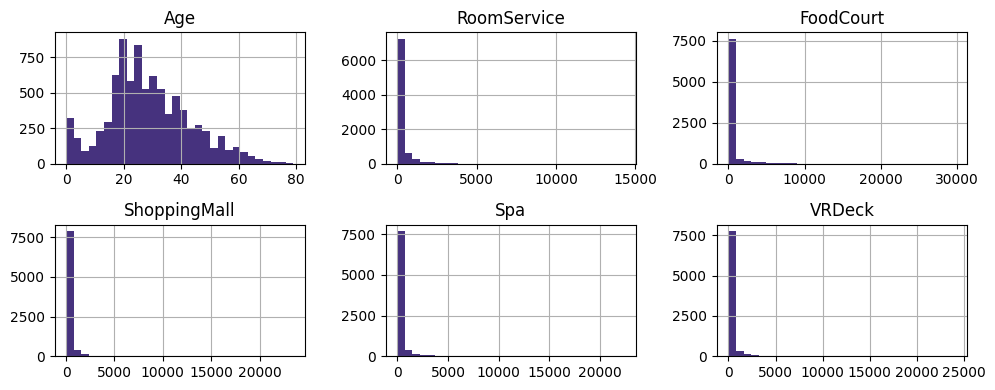

In [80]:
ncols = 3
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  df[col].dropna().hist(ax=axes[i], bins=30)
  axes[i].set_title(col)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

In [81]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
[cat_cols.remove(e) for e in ['PassengerId','Cabin', 'Name']]

[None, None, None]

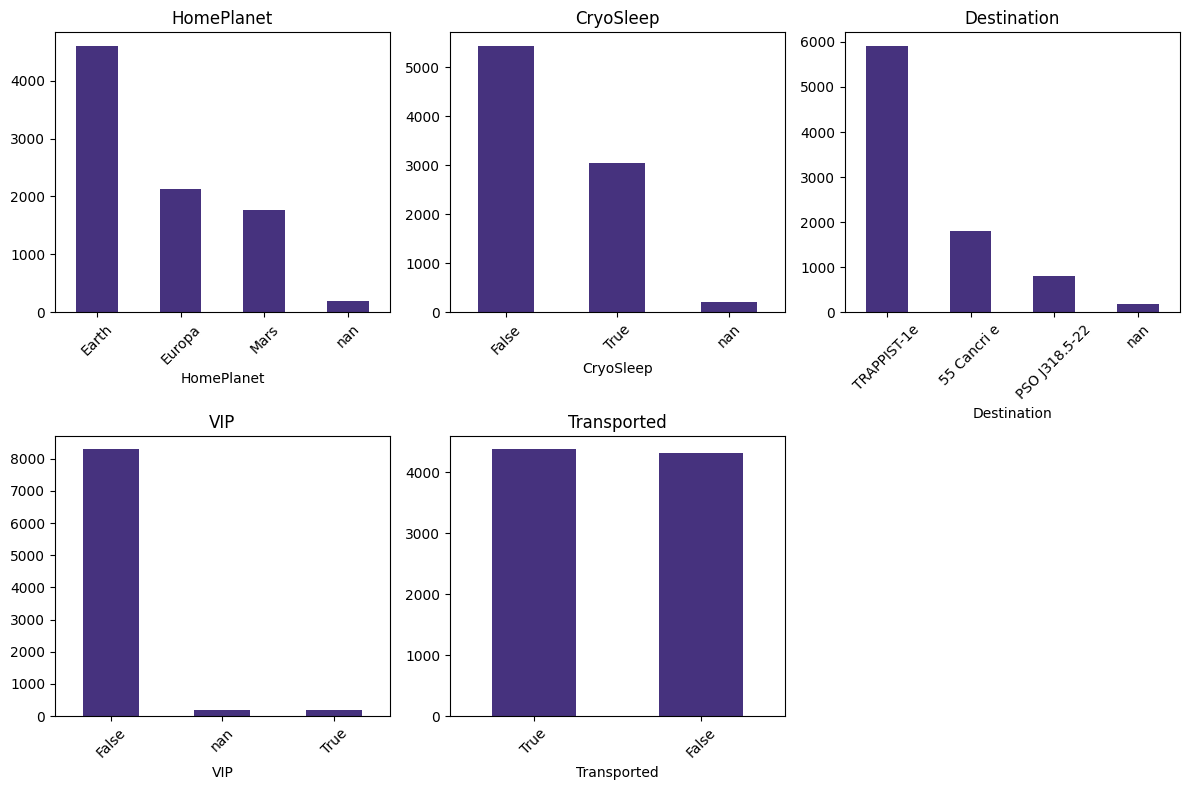

In [82]:
ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  df[col].value_counts(dropna=False).plot.bar(ax=axes[i])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=45)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

In [83]:
df['Transported'] = df['Transported'].astype(int)

In [84]:
corr_matrix = df.dropna()[df.select_dtypes(include='number').columns].corr()

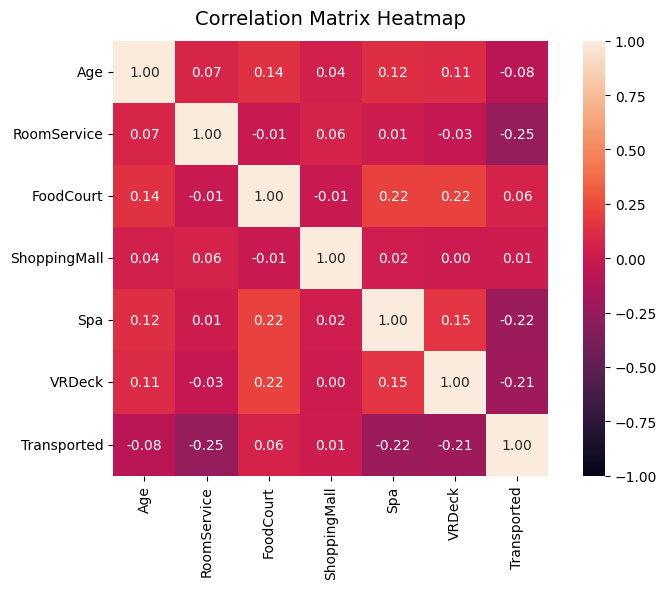

In [85]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [86]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


# **Data Preprocessing**

## **Feature Engineering**

In [87]:
df["CryoSleep"] = df["CryoSleep"].astype('Int64')
df["VIP"] = df["VIP"].astype('Int64')

In [88]:
split = df["PassengerId"].str.split("_", expand=True)

df["Group"] = split[0].astype(int)
df["Id"] = split[1].astype(int)

In [89]:
df["CabinMissing"] = df["Cabin"].isna().astype(int)

In [90]:
split = df["Cabin"].str.split("/", expand=True)

df["Deck"] = split[0]
df["CabinNumber"] = split[1].astype('Int64')
df["Side"] = split[2]

In [91]:
split = df["Name"].str.split(" ", expand=True)

split.nunique()

,0
0,2706
1,2217


In [92]:
df['FamilyName'] = split[1]

In [93]:
df.drop(['Cabin', 'PassengerId', 'Name'], axis=1, inplace=True)

In [94]:
df["HomePlanetMissing"] = df["HomePlanet"].isna().astype(int)
df["DestinationMissing"] = df["Destination"].isna().astype(int)

## **Encoding 1**

In [95]:
df = pd.get_dummies(
    df,
    columns=["HomePlanet", "Destination"],
    dtype=int
)

In [96]:
df["Side"] = df["Side"].map({"P": 0, "S": 1}).astype('Int64')

## **Splitting**

In [97]:
from sklearn.model_selection import StratifiedKFold

In [98]:
X = df.drop('Transported', axis=1)
y = df['Transported']

In [99]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_trains, X_tests, y_trains, y_tests = [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_trains.append(X.iloc[train_idx].copy())
    X_tests.append(X.iloc[test_idx].copy())
    y_trains.append(y.iloc[train_idx].copy())
    y_tests.append(y.iloc[test_idx].copy())

## **Encoding 2**

In [100]:
from sklearn.preprocessing import TargetEncoder

In [101]:
pd.concat([df.nunique(), df.dtypes], axis=1)

,0,1
CryoSleep,2,Int64
Age,80,float64
VIP,2,Int64
RoomService,1273,float64
FoodCourt,1507,float64
ShoppingMall,1115,float64
Spa,1327,float64
VRDeck,1306,float64
Transported,2,int64
Group,6217,int64


In [102]:
tg_enc_cols = [
    'Deck',
    'FamilyName'
]

In [107]:
for (X_train, y_train, X_test) in zip(X_trains, y_trains, X_tests):
  encoder = TargetEncoder(random_state=42)

  X_train[tg_enc_cols] = encoder.fit_transform(X_train[tg_enc_cols], y_train)
  X_test[tg_enc_cols] = encoder.transform(X_test[tg_enc_cols])

## **Data Imputation**

In [108]:
missing_vals_cols = [
  'CryoSleep',
  'Age',
  'VIP',
  'RoomService',
  'FoodCourt',
  'ShoppingMall',
  'Spa',
  'VRDeck',
  'CabinNumber',
  'Side'
]

In [117]:
df.isna().sum()

,0
CryoSleep,217
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183
VRDeck,188
Transported,0
Group,0


### KNNImputer

In [109]:
from sklearn.impute import KNNImputer

In [122]:
X_trains_knn, X_tests_knn = X_trains.copy(), X_tests.copy()

for (X_train, X_test) in zip(X_trains_knn, X_tests_knn):
  knn_imputer = KNNImputer(n_neighbors=5)

  X_train[missing_vals_cols] = knn_imputer.fit_transform(X_train[missing_vals_cols])
  X_test[missing_vals_cols] = knn_imputer.fit_transform(X_test[missing_vals_cols])

### Simple imputer

In [127]:
from sklearn.impute import SimpleImputer

In [128]:
X_trains_median, X_tests_median = X_trains.copy(), X_tests.copy()

for (X_train, X_test) in zip(X_trains_median, X_tests_median):
  imputer = SimpleImputer(strategy='median')

  X_train[missing_vals_cols] = imputer.fit_transform(X_train[missing_vals_cols])
  X_test[missing_vals_cols] = imputer.fit_transform(X_test[missing_vals_cols])

In [129]:
X_trains_mean, X_tests_mean = X_trains.copy(), X_tests.copy()

for (X_train, X_test) in zip(X_trains_mean, X_tests_mean):
  imputer = SimpleImputer(strategy='mean')

  X_train[missing_vals_cols] = imputer.fit_transform(X_train[missing_vals_cols])
  X_test[missing_vals_cols] = imputer.fit_transform(X_test[missing_vals_cols])

# **Feature Selection**

# **Model Training**

# **Model Finetuning**

# **Final Best Results**

# **Conclusion**